<a href="https://colab.research.google.com/github/Thjnh725/Practice_Deep_Learning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Nạp các thư viện cần thiết

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

### 2. Tải bộ dữ liệu Fashion MNIST và hiển thị kích thước các tập dữ liệu

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập huấn luyện y_train: {y_train.shape}")
print(f"Kích thước tập kiểm tra X_test: {X_test.shape}")
print(f"Kích thước tập kiểm tra y_test: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện X_train: (60000, 28, 28)
Kích thước tập huấn luyện y_train: (60000,)
Kích thước tập kiểm tra X_test: (10000, 28, 28)
Kích thước tập kiểm tra y_test: (10000,)


### 3. Tiền xử lý dữ liệu

In [3]:
# Reshape dữ liệu từ 3D thành 2D
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print(f"Kích thước X_train sau khi reshape: {X_train.shape}")
print(f"Kích thước X_test sau khi reshape: {X_test.shape}")

# Chuẩn hóa dữ liệu (Feature Scaling) bằng MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dữ liệu đã được chuẩn hóa.")

Kích thước X_train sau khi reshape: (60000, 784)
Kích thước X_test sau khi reshape: (10000, 784)
Dữ liệu đã được chuẩn hóa.


### 4. Xây dựng lại cấu trúc mạng ANN với các tham số tinh chỉnh

In [16]:
# Định nghĩa lại mô hình với tham số Dropout và L2 Regularization tinh chỉnh
model_optimized = Sequential([
    Dense(256, activation='relu', kernel_initializer='uniform',
          kernel_regularizer=l2(0.0001), input_shape=(784,)), # L2 Regularization giảm còn 0.0001
    Dropout(0.2), # Dropout rate giảm còn 0.2
    Dense(10, activation='softmax', kernel_initializer='uniform')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5
. Biên dịch mô hình đã tinh chỉnh

In [17]:
model_optimized.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
model_optimized.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

### 17. Huấn luyện mô hình đã tinh chỉnh với Early Stopping và số Epoch tăng

In [18]:
# Sử dụng lại Early Stopping callback

# Huấn luyện mô hình mới với Early Stopping và 40 epochs
model_fit_optimized = model_optimized.fit(X_train, y_train,
                                              validation_split=0.1,
                                              epochs=40, # Tăng số epoch tối đa
                                              callbacks=[early_stopping],
                                              verbose=1)

Epoch 1/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8094 - loss: 0.5624 - val_accuracy: 0.8592 - val_loss: 0.4311
Epoch 2/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8531 - loss: 0.4460 - val_accuracy: 0.8635 - val_loss: 0.4244
Epoch 3/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8632 - loss: 0.4233 - val_accuracy: 0.8753 - val_loss: 0.4008
Epoch 4/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8705 - loss: 0.4084 - val_accuracy: 0.8637 - val_loss: 0.4244
Epoch 5/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8709 - loss: 0.4028 - val_accuracy: 0.8758 - val_loss: 0.3978
Epoch 6/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8753 - loss: 0.3936 - val_accuracy: 0.8707 - val_loss: 0.4109
Epoch 7/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8759 - loss: 0.3914 - val_accuracy: 0.8728 - val_loss: 0.3954
Epoch 8/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8798 - loss: 0

### 6
. Trực quan hóa kết quả mô hình

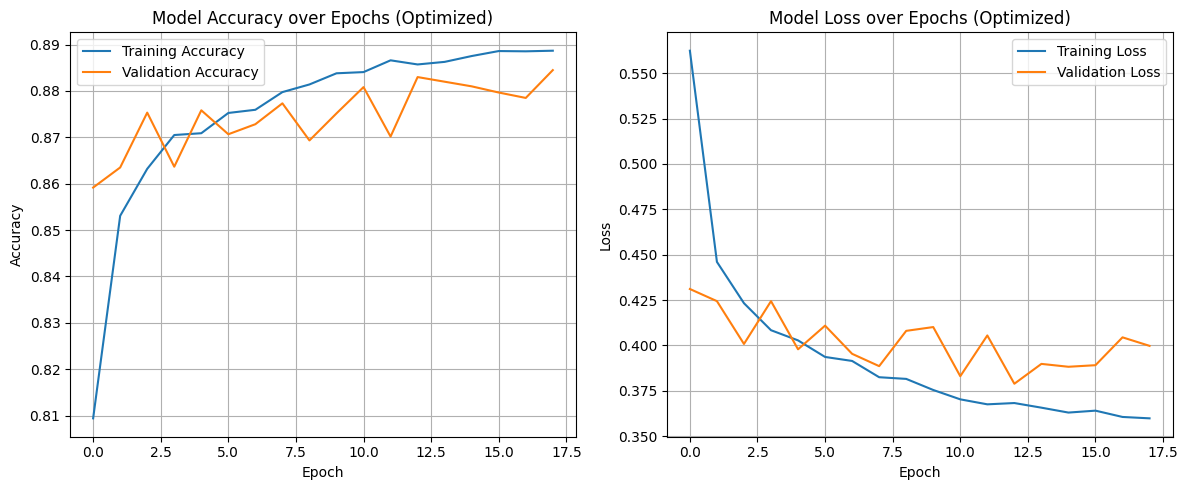

In [19]:
history_df_optimized = pd.DataFrame(model_fit_optimized.history)

# Vẽ biểu đồ độ chính xác
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_df_optimized['accuracy'], label='Training Accuracy')
plt.plot(history_df_optimized['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs (Optimized)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Vẽ biểu đồ hàm mất mát
plt.subplot(1, 2, 2)
plt.plot(history_df_optimized['loss'], label='Training Loss')
plt.plot(history_df_optimized['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs (Optimized)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 7. Đánh giá mô hình trên tập kiểm tra

In [20]:
loss_opt, accuracy_opt = model_optimized.evaluate(X_test, y_test, verbose=0)
print(f"Loss trên tập kiểm tra (mô hình tối ưu): {loss_opt:.4f}")
print(f"Độ chính xác trên tập kiểm tra (mô hình tối ưu): {accuracy_opt:.4f}")

Loss trên tập kiểm tra (mô hình tối ưu): 0.3996
Độ chính xác trên tập kiểm tra (mô hình tối ưu): 0.8757


### 8. Dự báo ảnh từ tập Test


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


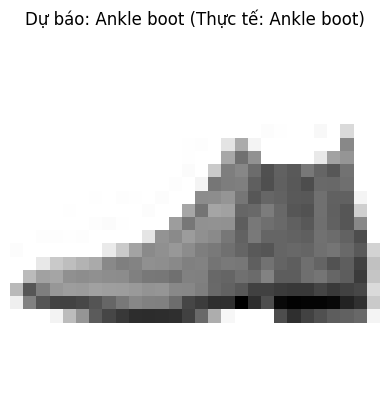


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


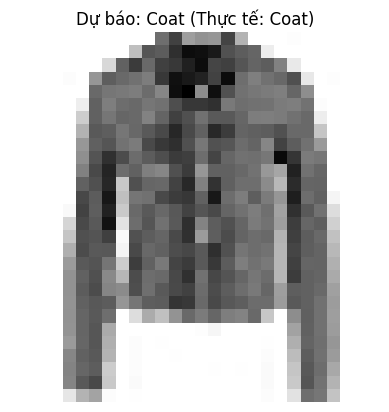


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


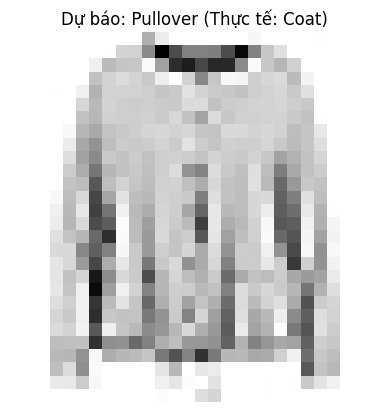


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


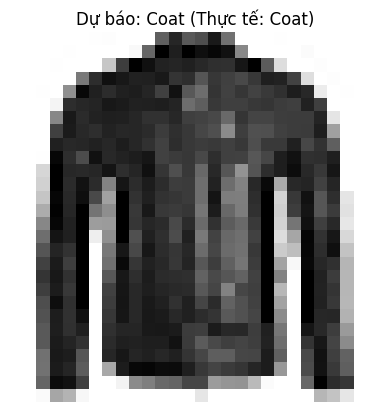


---



In [22]:
fashion_mnist_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

sample_indices = [0, 10, 25, 50]

for i in sample_indices:
    # Lấy ảnh và nhãn thực tế
    image_to_predict = X_test[i]
    true_label = y_test[i]

    input_image_for_prediction = image_to_predict.reshape(1, 784)

    # Thực hiện dự báo
    predictions = model_optimized.predict(input_image_for_prediction)
    predicted_label_index = np.argmax(predictions)
    predicted_label_name = fashion_mnist_class_names[predicted_label_index]
    true_label_name = fashion_mnist_class_names[true_label]

    plt.imshow(image_to_predict.reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Dự báo: {predicted_label_name} (Thực tế: {true_label_name})")
    plt.axis('off')
    plt.show()
    print("\n---\n")

### 9. Xuất báo cáo phân loại chi tiết (Classification Report & Confusion Matrix)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.79      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.77      0.78      1000
       Dress       0.85      0.91      0.88      1000
        Coat       0.78      0.81      0.80      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.66      0.69      0.67      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



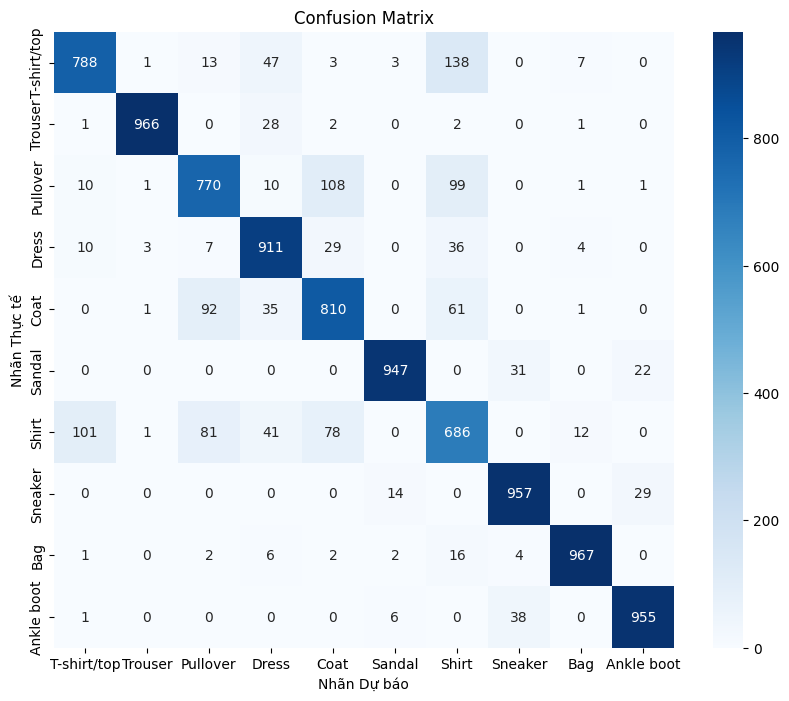

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Dự báo tất cả các nhãn trên tập test
y_pred_probabilities = model_optimized.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# In báo cáo phân loại
print("\n--- Báo cáo phân loại (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=fashion_mnist_class_names))

# Tạo và hiển thị Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_mnist_class_names, yticklabels=fashion_mnist_class_names)
plt.xlabel('Nhãn Dự báo')
plt.ylabel('Nhãn Thực tế')
plt.title('Confusion Matrix')
plt.show()

### 10. Dự báo một file ảnh tải lên từ bên ngoài

Saving download (4).jpg to download (4).jpg
Người dùng đã tải lên file "download (4).jpg"


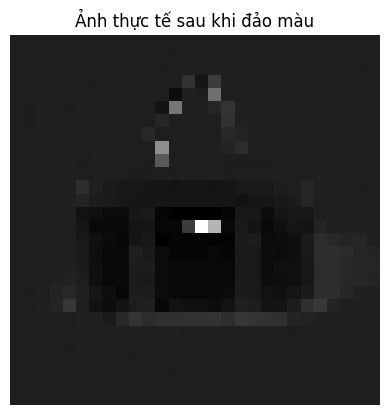

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Kết quả dự báo chính xác: 8 -> Bag


In [36]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

uploaded = files.upload()

for fn in uploaded.keys():
    print(f'Người dùng đã tải lên file "{fn}"')
    img_data = uploaded[fn]

    img = tf.keras.preprocessing.image.load_img(io.BytesIO(img_data), color_mode='grayscale', target_size=(28, 28))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.squeeze(img_array).numpy()
    img_inverted = 255.0 - img_array

    img_normalized = img_inverted / 255.0

    plt.imshow(img_normalized, cmap='gray')
    plt.title("Ảnh thực tế sau khi đảo màu")
    plt.axis('off')
    plt.show()

    img_flat = img_normalized.reshape(1, 784)

    img_predict = model_optimized.predict(img_flat)
    score = np.argmax(img_predict)
    predicted_label_name = class_names[score]

    print(f"Kết quả dự báo chính xác: {score} -> {predicted_label_name}")